In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.morphology import watershed
from skimage.feature import peak_local_max

In [3]:
x, y = np.indices((80, 80))
x1, y1, x2, y2 = 28, 28, 44, 52
r1, r2 = 16, 20
mask_circle1 = (x - x1)**2 + (y - y1)**2 < r1**2
mask_circle2 = (x - x2)**2 + (y - y2)**2 < r2**2
image = np.logical_or(mask_circle1, mask_circle2)

In [5]:
distance = ndi.distance_transform_edt(image)
local_maxi = peak_local_max(distance, indices=False,
                            footprint=np.ones((3, 3)),
                            labels=image)
markers = ndi.label(local_maxi)[0]

In [6]:
labels = watershed(-distance, markers, mask=image)

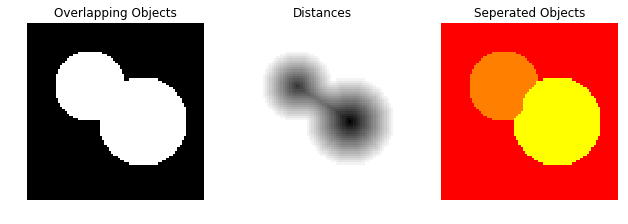

In [9]:
fig, axes = plt.subplots(ncols=3, figsize=(9, 3),
                         sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Overlapping Objects')
ax[1].imshow(-distance, cmap=plt.cm.gray)
ax[1].set_title('Distances')
ax[2].imshow(labels, cmap=plt.cm.autumn)
ax[2].set_title('Seperated Objects')

for a in ax:
    a.set_axis_off()

fig.tight_layout()
plt.show()